# Fit nonlinear function to network performance

This script takes in the results from data-overview.ipynb, and performs a regression to extract the impact of different regulatory parameters on the data.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.backends.backend_pdf import PdfPages

import matplotlib as mpl
import matplotlib.ticker as ticker

import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go
import plotly.express as px
import pickle
import time

# import clustering packages
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline, interp1d
from scipy.signal import savgol_filter

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm
from joblib import Parallel, delayed

from stoch_sim_model import *

In [2]:
# Load data from 2nd infections
reg_model = ''
runs = '-3-'
comment = "acute_all-sparse-reg"
d = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'
d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/processed_full_data'+runs+'runs'+'-'+comment+'.pkl'
# d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl'

# Import datasets
clustered_mean_df = pd.read_pickle(d_mean)
# '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/list_processed_data'+runs+'runs'+'-'+comment+'.pkl'
with open('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/list_processed_full_data'+runs+'runs'+'-'+comment+'.pkl', 'rb') as f:
    infection_scenarios = pickle.load(f)

with pd.option_context('display.max_columns', None):
    display(clustered_mean_df)

,b_I,d_I,K_I,I_0,S_0,N_0,d_S,K_H,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,harm_pI,harm_pS,max_eM_fold,frac_cM,log_T_pEcyteM,T_min_pI,T_max_pI,T_pE_start,T_pE_clear,stim_pI,stim_pHI,stim_pHE,scaled_min_pS,antigenicity_over_harm,harm_pI_noprotection,peff_clearance,peff_toxicity
0,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,-1.5,3.0,-1.5,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-4.0,1.095488e+07,35106.380802,2.149342,0.146766,0.057037,0.0,9.29,1.16,-4.75,6.513046,1.782661,0.217704,0.015272,3.349148,5.516209,0.038768,0.017553
1,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,-1.5,3.0,-1.5,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-2.0,1.100187e+07,11985.589440,1.705693,0.166667,0.045352,0.0,8.94,1.44,-4.57,6.521897,1.789863,0.070887,0.015121,3.349148,5.516209,0.015276,0.005993
2,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,-1.5,3.0,-1.5,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.102732e+07,1204.606980,0.757396,0.171642,0.014280,0.0,8.74,20.00,-6.88,6.525916,1.793136,0.004632,0.015052,3.349148,5.516209,0.002551,0.000602
3,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,-1.5,3.0,-1.5,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.102977e+07,556.347821,0.531479,0.129353,0.008326,0.0,8.71,20.00,-6.97,6.526133,1.793312,0.002679,0.015048,3.349148,5.516209,0.001323,0.000278
4,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,-1.5,3.0,-1.5,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.103020e+07,464.908061,0.465383,0.174564,0.006561,0.0,8.71,20.00,-6.66,6.526160,1.793335,0.001838,0.015048,3.349148,5.516209,0.001111,0.000232
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219374995,1.000000e-01,0.01,10000000.0,500000.0,10000000.0,1000.0,0.01,100000.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.5,0.0,3.0,4.0,5.643291e+06,0.000000,0.000000,0.000000,0.000000,0.0,20.00,20.00,0.00,0.267860,1.188038,0.000000,0.761217,5.611731,2.821645,0.000000,0.000000
219374996,1.000000e-01,0.01,10000000.0,500000.0,10000000.0,1000.0,0.01,100000.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.5,1.5,-3.0,-4.0,5.643291e+06,0.000000,0.000000,0.000000,0.000000,0.0,20.00,20.00,0.00,0.267860,1.188038,0.000000,0.761217,5.611731,2.821645,0.000000,0.000000
219374997,1.000000e-01,0.01,10000000.0,500000.0,10000000.0,1000.0,0.01,100000.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.5,1.5,-3.0,-2.0,5.643291e+06,0.000000,0.000000,0.000000,0.000000,0.0,20.00,20.00,0.00,0.267860,1.188038,0.000000,0.761217,5.611731,2.821645,0.000000,0.000000
219374998,1.000000e-01,0.01,10000000.0,500000.0,10000000.0,1000.0,0.01,100000.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.5,1.5,-3.0,0.0,5.643291e+06,0.000000,0.000000,0.000000,0.000000,0.0,20.00,20.00,0.00,0.267860,1.188038,0.000000,0.761217,5.611731,2.821645,0.000000,0.000000


In [3]:
# Define parameters
num_categories = len(perf_vars)
num_modules = len(modules)

module_reg = {'Na': [r for r in Na_reg if np.std(infection_scenarios[10][r].values) > 0], 
              'NE': [r for r in NE_reg if np.std(infection_scenarios[10][r].values) > 0],  
              'EM': [r for r in EM_reg if np.std(infection_scenarios[10][r].values) > 0], 
              'EE': [r for r in EE_reg if np.std(infection_scenarios[10][r].values) > 0]}

module_reg_labels = {'Na': [r for i, r in enumerate(param_names[-16:-12]) if  Na_reg[i] in module_reg['Na']], 
                     'NE': [r for i, r in enumerate(param_names[-12:-8]) if  NE_reg[i] in module_reg['NE']],
                     'EM': [r for i, r in enumerate(param_names[-8:-4]) if  EM_reg[i] in module_reg['EM']],
                     'EE': [r for i, r in enumerate(param_names[-4:]) if  EE_reg[i] in module_reg['EE']]}
reg_label = param_names[-16:]
signal_classes = [r for i, r in enumerate(["Ag.", "Inf. harm", "Resp. harm", "Baselines"]) if np.std(infection_scenarios[0][[Na_reg[i]] + [NE_reg[i]] + [EM_reg[i]] + [EE_reg[i]]].values) > 0]

reg = [r for r in Na_reg + NE_reg + EM_reg + EE_reg if np.std(infection_scenarios[10][r].values) > 0]
key_var = 'antigenicity_over_harm'
n_virs = len(infection_scenarios)
cmap_colors = sns.color_palette('tab20c', 20)
tol = 1e-2

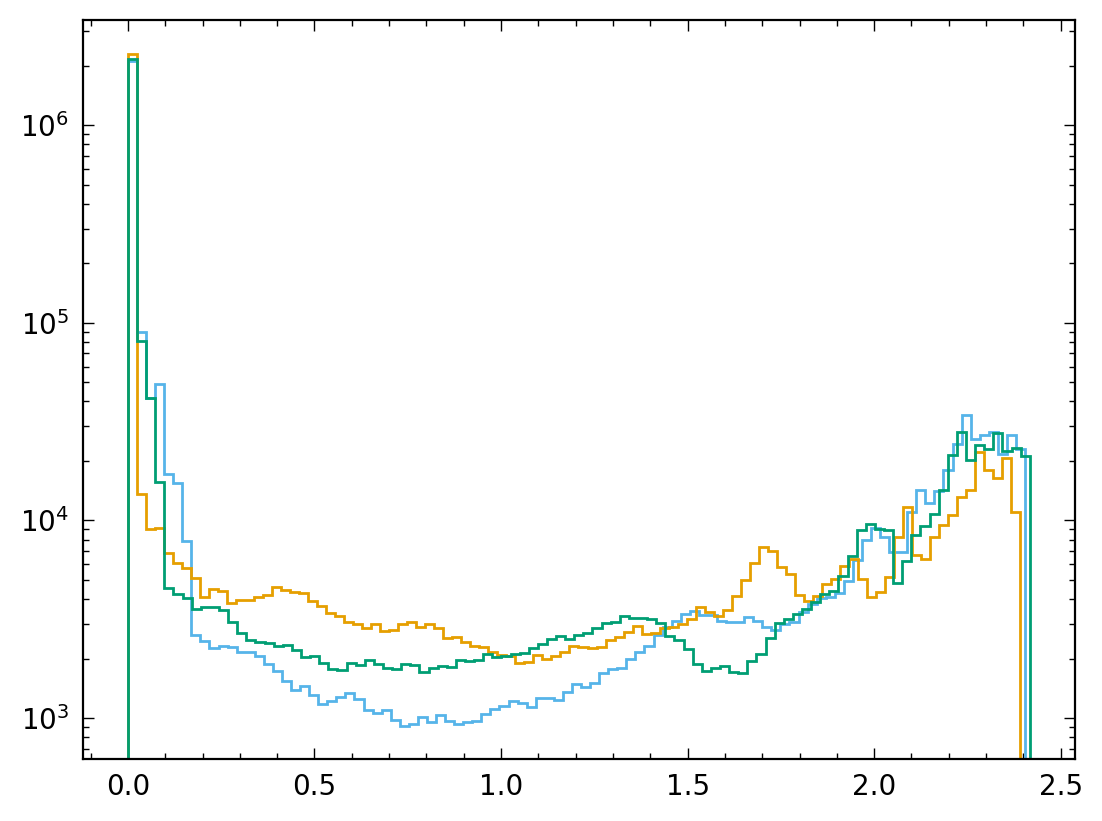

In [4]:
# Inspect distribution of observables
sel = 'peff_clearance'
for a in np.unique(clustered_mean_df.loc[(clustered_mean_df.b_I == b_C)][key_var].values):
    data = clustered_mean_df.loc[clustered_mean_df[key_var] == a]
    plt.hist(data[sel], bins = np.linspace(np.amin(data[sel]), np.amax(data[sel]), 100), histtype = 'step', log = True);

,antigenicity_over_harm,stim_pI,stim_pHI,stim_pHE
0,-10.445414,3.456836,1.188038,3.668819
1,0.532046,0.000100,0.007459,3.497857
2,0.544286,0.000629,0.041485,3.495795
3,0.556817,0.003741,0.205174,3.503453
4,0.562162,0.000164,0.007459,3.500244
...,...,...,...,...
223,2.964652,6.092953,2.124410,3.474484
224,3.120998,6.308881,2.026495,3.479383
225,3.349148,6.526300,1.793448,3.523518
226,5.611731,0.267860,1.188038,3.725538


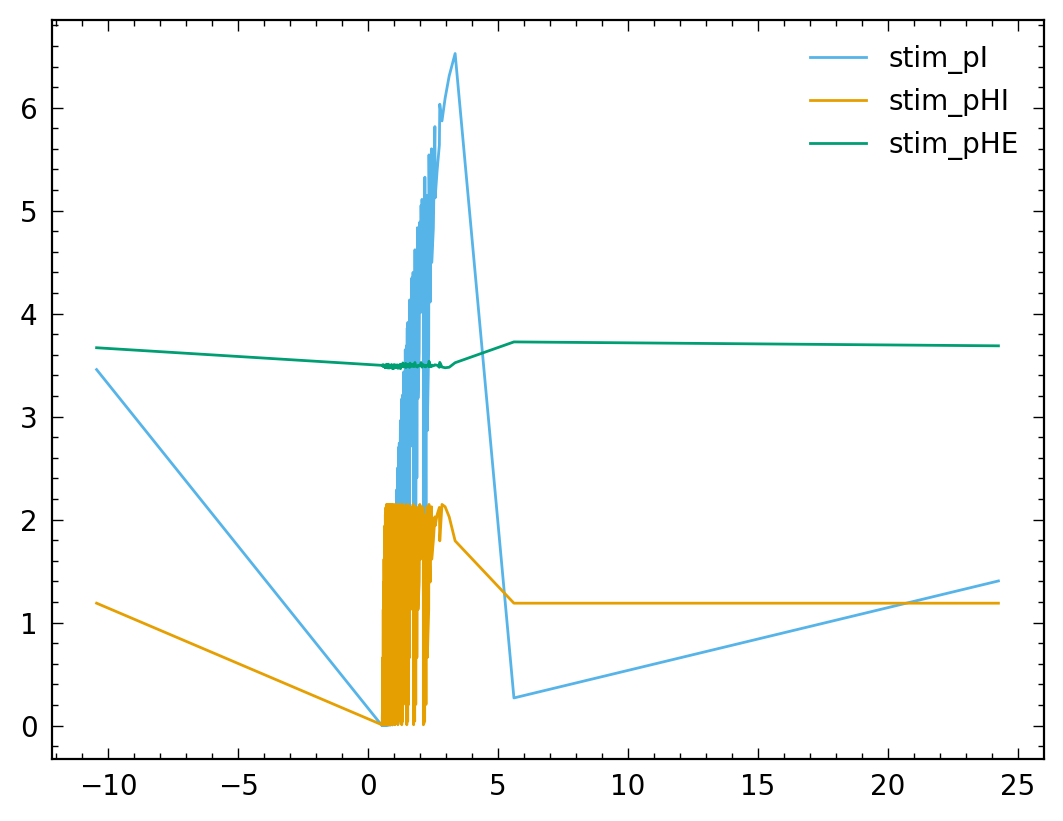

In [5]:
#norm_stim = clustered_mean_df.loc[(np.sum(np.abs(clustered_mean_df[reg_stim]), axis = 1) == 0)].groupby(key_var, as_index = False).mean()[[key_var, 'stim_pI', 'stim_pHI', 'stim_pHE']]
norm_stim = clustered_mean_df.groupby(key_var, as_index = False).max()[[key_var, 'stim_pI', 'stim_pHI', 'stim_pHE']]
with pd.option_context('display.max_columns', None):
    display(norm_stim)
    
plt.plot(norm_stim[key_var], norm_stim[['stim_pI', 'stim_pHI', 'stim_pHE']], label = ['stim_pI', 'stim_pHI', 'stim_pHE'])
plt.legend()

### Fit model to average data
The nonlinear sigmoid model does a good job on the data averaged over infections and marginalized over modules. This is the minimum we require.

fevals: 16
fevals: 68
fevals: 8
fevals: 12
fevals: 58
fevals: 108
fevals: 60
fevals: 17
fevals: 10
fevals: 59
fevals: 8
fevals: 9
fevals: 10
fevals: 59
fevals: 8
fevals: 9


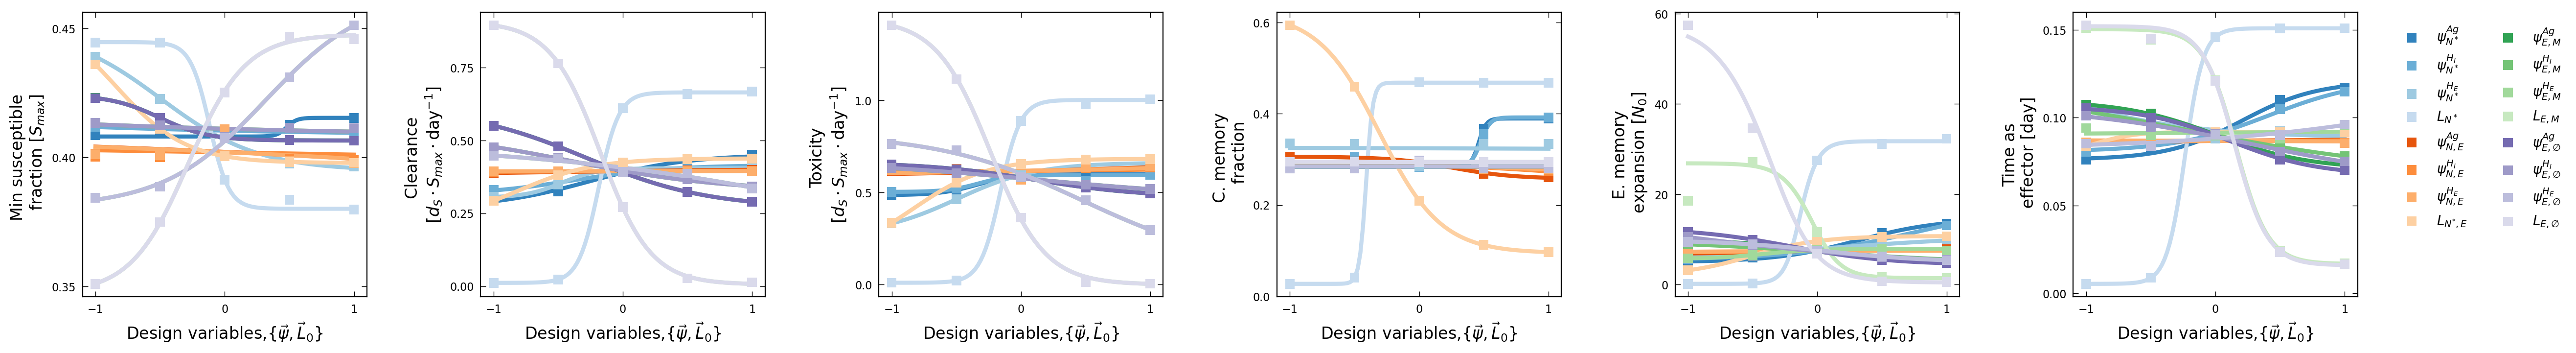

In [6]:
# Fit impact of regulatory parameters on performace: marginalizing over modules
fig, axs = plt.subplots(1, len(perf_vars), 
                              figsize=(len(perf_vars)**2 - len(perf_vars), 4), sharex=True, sharey=False)

for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    zero_regs = np.concatenate([(module_reg[modules[u]] if u != module_index else []) for u in np.arange(0, len(modules))]).tolist()
    
    x_varname= key_var

    for j, p in enumerate(signal_classes):
        data_mean = clustered_mean_df.groupby(reg_choice[j], as_index = False).mean()
        
        for i, var in enumerate(perf_vars):
            im = axs[i].scatter(data_mean[reg_choice[j]]/np.amax(data_mean[reg_choice[j]]), 
                                (10**data_mean[var] - 1) if i == 4 or i == 5 else data_mean[var], 
                              marker = 's', s = 50, color = cmap_colors[module_index*len(reg_choice) + j], 
                                edgecolors = 'None',label = reg_label[module_index*len(reg_choice) + j ])

            y_max = np.max(data_mean[var].values)
            y_min = np.min(data_mean[var].values)
            y_std = np.std(data_mean[var].values)

            popt, pcov, infodict, _, _ = curve_fit(sigmoid_1d, data_mean[reg_choice[j]].values, data_mean[var].values, 
                                   p0 =(y_max, y_min, 0.0, 0.0),
                                   method = 'trf', 
                                   bounds = ([y_max - tol*y_std, np.minimum(2*y_min, 0), -4*L0_max, -4*L0_max], 
                                             [2*y_max if y_max > 0 else y_std*tol, np.maximum(y_min, 0) + y_std*tol, 4*L0_max, 4*L0_max]),
                                   maxfev=10000,
                                   full_output = True)

            x = np.linspace(-np.max(data_mean[reg_choice[j]]), np.max(data_mean[reg_choice[j]]), 100)
            axs[i].plot(x/np.amax(x), (10**sigmoid_1d(x, *popt) - 1) if i == 4 or i == 5 else sigmoid_1d(x, *popt), 
                        linestyle='-',
                        linewidth = 3.0,
                        color = cmap_colors[module_index*len(reg_choice) + j], 
                        zorder = 0)

            if i == 0:
                print("fevals:", infodict['nfev'])

            if module_index + j == 0: 
                axs[i].minorticks_off()
                axs[i].yaxis.set_tick_params(labelbottom=True)
                axs[i].xaxis.set_tick_params(labelbottom=True)
                axs[i].tick_params(axis='both', which='major', labelsize=8)
                axs[i].set_box_aspect(1)
                axs[i].locator_params(axis='y', nbins=4)
                axs[i].locator_params(axis='x', nbins=4)
                axs[i].set_ylabel(perf_labels[i], fontsize = 12)
                axs[i].set_xlabel(r'Design variables,$\{\vec\psi, \vec L_0 \}$', fontsize = 12)

axs[-1].legend(bbox_to_anchor=(1.1, 1), fontsize=10, framealpha=0, ncol = 2)
fig.subplots_adjust(wspace=.4, hspace=.35)
plt.savefig('_figs/'+comment+'-'+'mean_regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")

In [7]:
del clustered_mean_df

### Fit model to individual infection scenarios and with all regulatory modules as variables

In [8]:
# Regress Performance measures on regulation parameters
num_cpu = 140
variables = reg
tol = 1e-2

def model(input, fit = "non-linear"):

    out = []
    infection = input[vir_vars].values[0]
    runtimes = str(np.round(infection, 3))+': '
    
    for i, perf in enumerate(perf_vars):
        # run regression
        start = time.time() # timestamp start
        
        if fit == "linear":
            input.loc[:,'dep_var'] = np.log(1 + input[perf].values) if 'Memory' in perf_labels[perf_vars.index(perf)] or 'magnitude' in perf_labels[perf_vars.index(perf)] else input[perf].values
            lr = smf.ols('dep_var ~ ' + ' + '.join(variables), data=input).fit()
    
            # save values
            out.append( (lr.params.values[0: 1 + len(variables)]).tolist() + np.sqrt(np.diag(lr.cov_params())).tolist() + infection.tolist() + [np.mean(input[perf].values), i] )
        else:
            y_max = np.max(input[perf].values)
            y_min = np.min(input[perf].values)
            y_std = np.std(input[perf].values)
            popt, pcov = curve_fit(sigmoid, input[variables].values, input[perf].values, 
                           p0 =[y_max, y_min] + len(variables)*[0.0] + num_modules*[0.0],
                           method = 'trf', 
                           bounds = ([y_max - y_std*tol, np.minimum(0.0, y_min)] + len(variables)*[-15*L0_max] + num_modules*[-15*L0_max], 
                                     [1.0 if perf == "frac_cM" else (y_max + y_std*tol), y_min + y_std*tol] + len(variables)*[15*L0_max] + num_modules*[15*L0_max]), 
                                   maxfev=100000,
                                   full_output = False)
            
            residuals = input[perf].values - sigmoid(input[variables].values, *popt)
            rmse = np.sqrt(np.mean(residuals**2))
            out.append(popt.tolist() + np.sqrt(np.diag(pcov)).tolist() + infection.tolist() + [np.mean(input[perf].values), 
                                                                                               np.max(input[perf].values), 
                                                                                               np.min(input[perf].values), 
                                                                                               np.median(input[perf].values), 
                                                                                               i, rmse, y_std, 
                                                                                               np.amax(input['scaled_min_pS'].values),
                                                                                               input['harm_pI_noprotection'].values[0],
                                                                                               np.amax(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pI'].values), 
                                                                                               np.amax(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pHI'].values),
                                                                                               np.amax(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pHE'].values)])

            # if i == 0:
            #     print("fevals:", infodict['nfev'])
        end = time.time() # timestamp start
        runtimes += (perf+ ' = ' + str((end - start)/3600)+' hrs, ')
        
    #print(runtimes)
    out_data = pd.DataFrame(np.vstack(out), 
                            columns = ['y_max', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'max_scaled_min_pS', 'harm_pI_noprotection', 'stim_pI', 'stim_pHI', 'stim_pHE'])
    out_data['antigenicity_over_harm'] = antigenicity_over_harm(out_data)
    out_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'+comment+runs+'fit_'+str(np.round(infection, 3))+'.pkl')
    
    return np.vstack(out)

# Compile datasets
impact_data = pd.DataFrame(np.vstack(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(model)(input = data.groupby(vir_vars + variables, as_index=False).mean(), fit = "nonlinear") 
                                                                                                            for data in infection_scenarios)), 
                            columns = ['y_max', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'max_scaled_min_pS', 'harm_pI_noprotection', 'stim_pI', 'stim_pHI', 'stim_pHE'])
impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [9]:
# # IF the above fails: Compile datasets
# num_cpu = 150
# file_list = [f for f in os.listdir(d) if comment in f]
# num_files = len(file_list)

# def import_fits(f,d):
    
#     file_path = os.path.join(d, f)
#     with open(file_path, 'rb') as filename:  
#         out = pickle.load(filename)

#     return out

# impact_data = pd.concat(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(import_fits)(f = file_name, d = d) 
#                                                                                                             for file_name in file_list))
# impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

# impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [23]:
# View result
perf_choice = 1 # chose observable
impact_data = pd.read_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')
with pd.option_context('display.max_columns', None,'display.max_rows', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)])

,y_max,y_min,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_myc_I,sigma_psi_myc_HI,sigma_psi_myc_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_Edie_I,sigma_psi_Edie_HI,sigma_psi_Edie_HE,sigma_L0_Edie,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_I,b_I,K_H,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,max_scaled_min_pS,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
1,5.524459,1.614129e-02,3.914052,0.030487,0.111774,3.914749,0.314775,-0.000747,-0.014618,1.075475,-8.030141,-0.347087,-0.456941,-4.317609,-7.801836,-0.326201,-0.437192,-4.188998,3.569975,5.268144,-2.143704,-2.133505,0.004242,0.000977,3.163043e-02,5.190657e-03,5.241121e-03,3.188901e-02,0.005511,0.005257,0.005258,1.475507e-02,0.053183,0.007452,0.007905,0.030532,0.050733,0.007268,0.007724,0.028981,3.179439e-02,5.979710e-02,0.009190,0.009101,0.150000,1.000000e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,0.604043,5.508317,0.0,0.000510,1.0,0.484432,1.614129,0.967943,5.516209,6.526300,1.793448,3.321922,3.349148
7,5.522994,1.603299e-02,3.704949,0.055994,0.176088,4.085953,0.211536,0.007690,-0.001123,1.218673,-5.339303,-0.264381,-0.345864,-3.158452,-5.245142,-0.256483,-0.341325,-3.110704,3.353518,5.937975,-1.944244,-1.930807,0.004980,0.001025,3.197811e-02,5.819096e-03,5.959316e-03,3.428202e-02,0.005979,0.005861,0.005861,2.369797e-02,0.033234,0.005551,0.005714,0.022014,0.032264,0.005473,0.005636,0.021399,2.885839e-02,9.579517e-02,0.008154,0.008060,0.150000,1.637894e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,0.597839,5.506961,0.0,0.000460,1.0,0.507987,1.603299,0.941492,5.516209,6.033823,1.793448,3.337601,2.758122
13,5.521194,1.588892e-02,4.261562,0.073183,1.005654,6.479532,0.138905,0.023895,0.005157,1.027897,-4.344056,-0.185561,-0.377734,-4.284959,-4.345427,-0.186814,-0.381356,-4.285945,3.384121,5.027281,-2.109500,-2.107498,0.004392,0.000941,4.404175e-02,6.946594e-03,1.258137e-02,6.555684e-02,0.005056,0.005005,0.005003,1.397972e-02,0.026596,0.005360,0.005804,0.023904,0.026601,0.005361,0.005813,0.023916,3.251655e-02,5.659510e-02,0.008677,0.008664,0.150000,2.682696e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,0.589065,5.505305,0.0,0.000405,1.0,0.471421,1.588892,0.923918,5.516209,5.541939,1.793448,3.346386,2.344404
19,5.518302,1.574230e-02,3.089434,0.109527,1.031050,5.715008,0.103229,0.010291,-0.003417,1.062239,-3.961879,-0.205878,-0.382607,-4.209827,-3.937065,-0.200115,-0.374178,-4.179493,3.037072,5.166124,-2.166201,-2.167775,0.004132,0.000884,2.672853e-02,6.674609e-03,1.052967e-02,4.472069e-02,0.004775,0.004748,0.004748,1.418611e-02,0.019747,0.004913,0.005386,0.020619,0.019541,0.004880,0.005335,0.020377,2.237868e-02,5.739597e-02,0.008554,0.008559,0.150000,4.393971e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,0.578890,5.502560,0.0,0.000346,1.0,0.442866,1.574230,0.911572,5.516209,5.051025,1.793448,3.353715,2.038612
25,5.514514,1.556484e-02,3.412497,0.197814,1.862952,9.955125,0.070220,-0.002133,0.004546,1.168585,-2.695962,-0.281947,-0.542862,-3.278252,-2.710792,-0.297375,-0.542986,-3.327945,3.737464,5.624134,-2.036764,-2.036277,0.004081,0.000843,3.579037e-02,8.662156e-03,2.262308e-02,1.037363e-01,0.004643,0.004631,0.004631,1.721932e-02,0.012526,0.004175,0.004736,0.014762,0.012714,0.004234,0.004770,0.015176,3.971442e-02,6.958521e-02,0.007190,0.007203,0.150000,7.196857e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,0.566123,5.498949,0.0,0.000294,1.0,0.422428,1.556484,0.892363,5.516209,4.561689,1.793448,3.351424,1.803387
31,5.510946,1.525433e-02,2.966987,0.240201,2.895171,11.304729,0.060155,0.007548,0.003831,1.133412,-1.985517,-0.291080,-0.735588,-3.227248,-1.968913,-0.289642,-0.730447,-3.16884

#### Check the model goodness of the fit
The model does a pretty good job as the $R^2$ values for clearance, toxicity and memory are above 0.80.

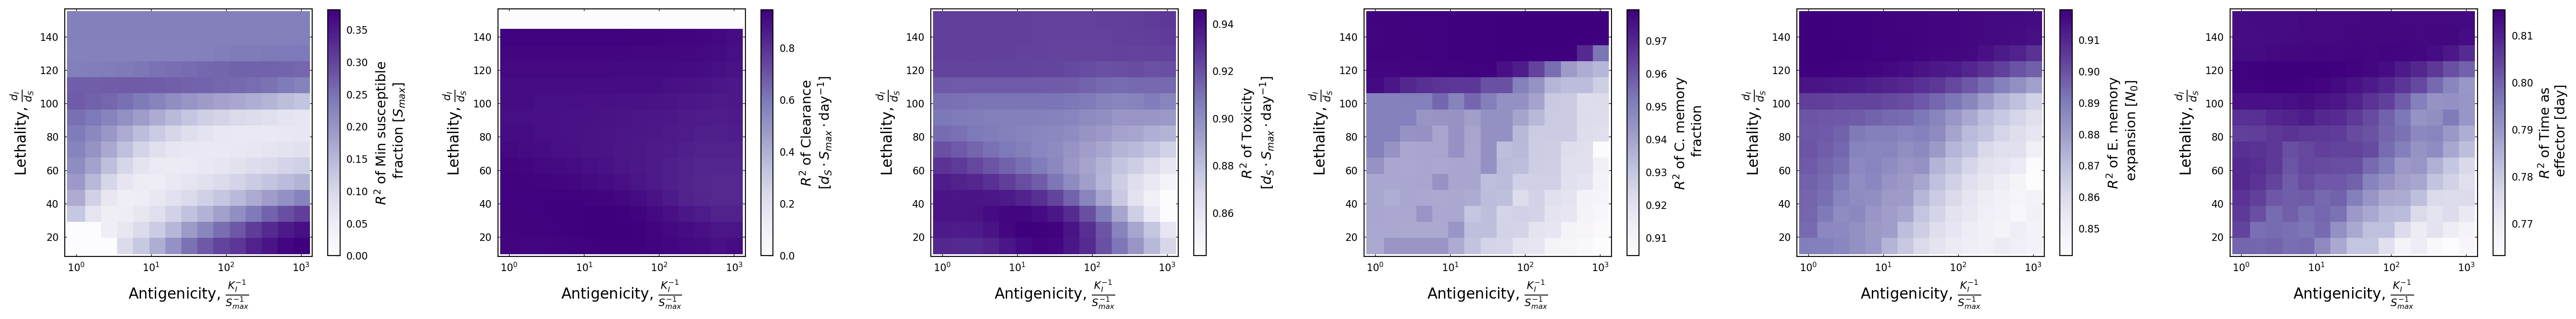

In [24]:
# Examine goodness of fit through R-squared
plots = [vir_vars[1], vir_vars[0]]
plot_labels = ["Antigenicity, "+r"$\frac{K_{I}^{-1}}{S_{max}^{-1}}$", "Lethality, "+r"$\frac{d_{I}}{d_{S}}$"]
size = 3200/np.sqrt(len(infection_scenarios))

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_min)]
    model_r_sq = (1 - data.rmse**2/data.y_std**2)*(data.y_std > tol)
    z_label = r"$R^2$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, c = model_r_sq, cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-r-squared'+'.png', dpi=150, bbox_inches="tight")

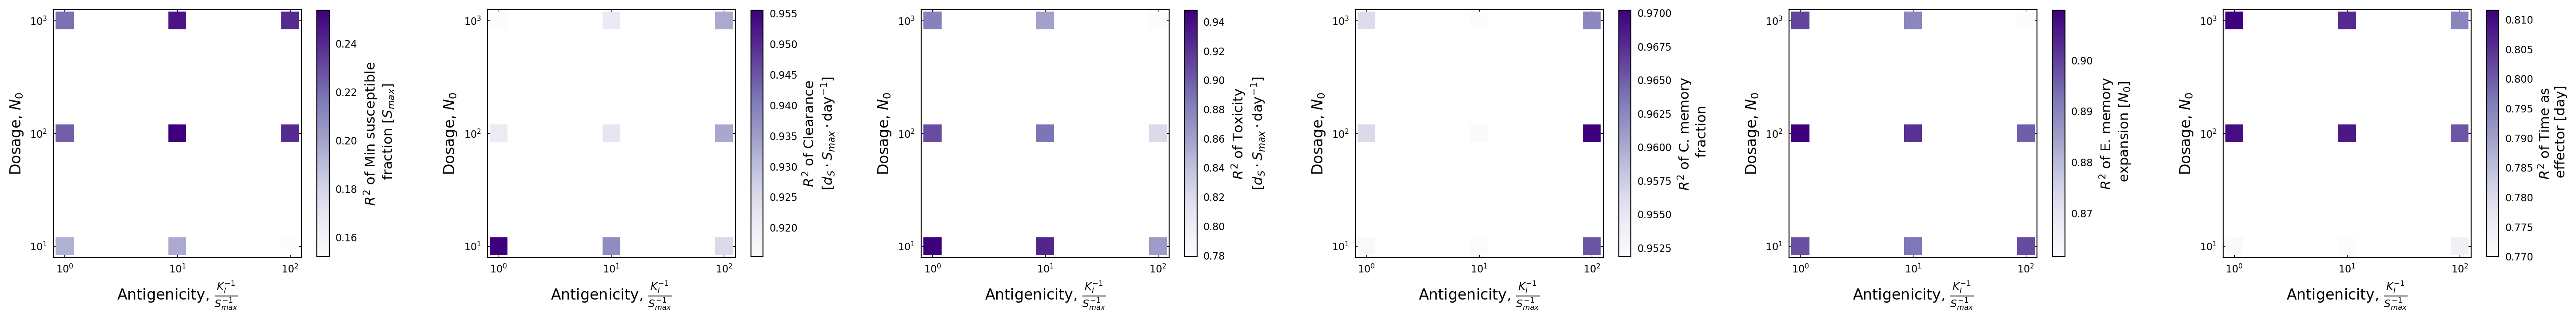

In [25]:
# Examine goodness of fit through R-squared
size = 3200/np.sqrt(len(infection_scenarios))

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = vir_vars[1], vir_vars[4]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 > I_min)]
    model_r_sq = (1 - data.rmse**2/data.y_std**2) #*(data.y_std > tol)
    z_label = r"$R^2$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname], data[y_varname],
                      marker ='s', s = size, c = model_r_sq, cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    axs[i].semilogx()
    axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel("Antigenicity, "+r"$\frac{K_{I}^{-1}}{S_{max}^{-1}}$", fontsize = 12)
    ax.set_ylabel("Dosage, "+r"$N_0$", fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-r-squared-cancers'+'.png', dpi=150, bbox_inches="tight")

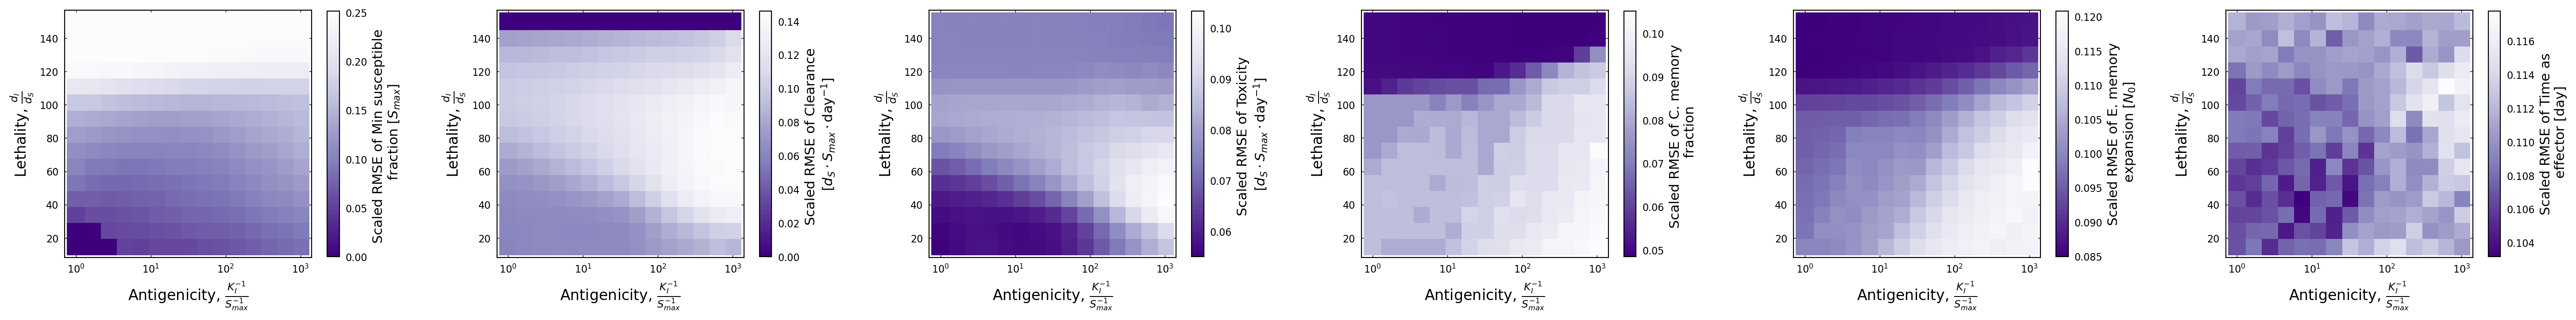

In [26]:
# Examine goodness of fit through scaled-RMSE
fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_min)]
    model_rmse_over_max = (data.rmse/data.y_max)*(data.y_std > tol)
    z_label = "Scaled RMSE of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, 
                        c = model_rmse_over_max, cmap='Purples_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-scaled-rmse'+'.png', dpi=150, bbox_inches="tight")

Effector memory expansion appears challenging to fit based on the $R^2$ values. Looks much better when we look at scaled RMSE. Rationalize by observing tha effector memory expansion has non-monotonic dependence on some variables which can lead to a low variance estimate, and make the $R^2$ values look bad.

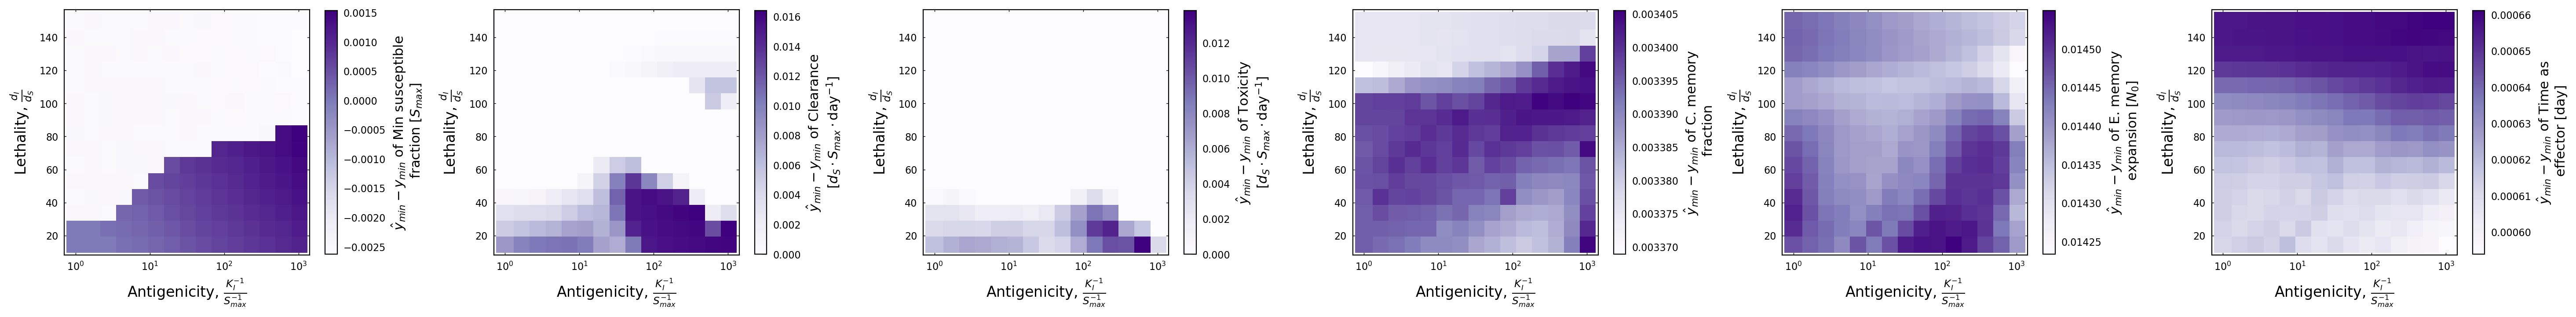

In [27]:
# Examine difference between observed and predicted minima
fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_min)]
    z_label = r"$\hat{y}_{min} - y_{min}$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, c = (data.y_min - data.min_perf)*(data.y_std > tol), cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-y_min'+'.png', dpi=150, bbox_inches="tight")

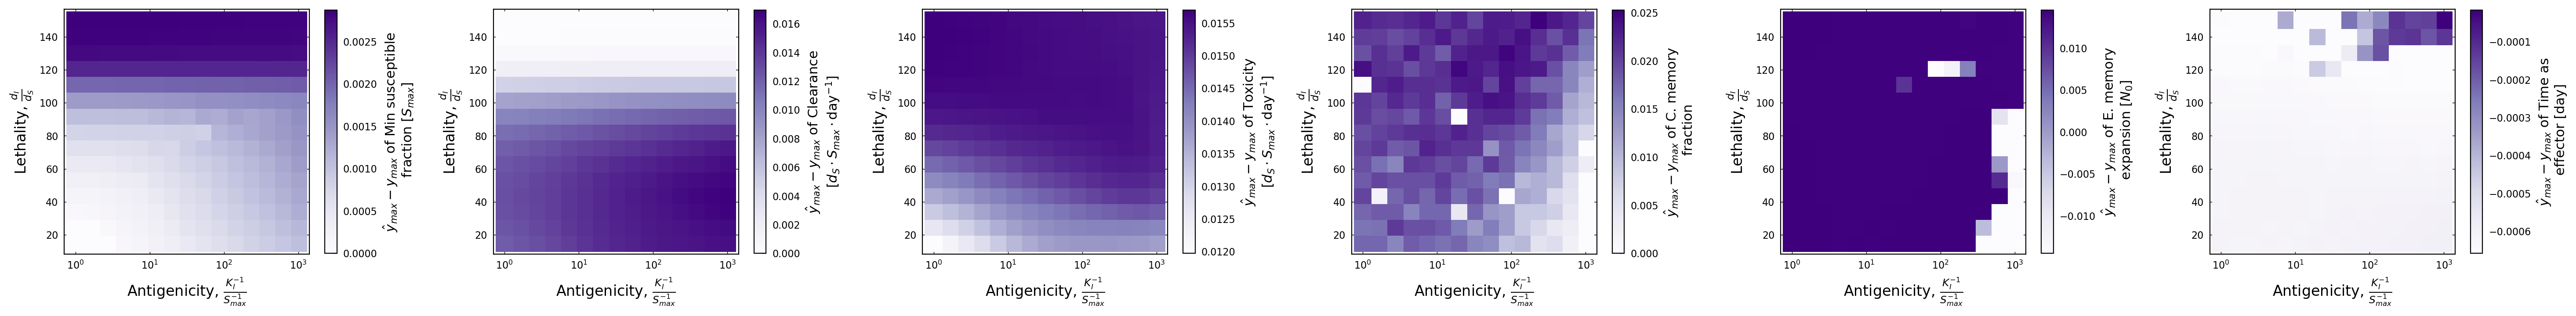

In [28]:
# Examine difference between observed and predicted maxima
plots = [vir_vars[1], vir_vars[0]]

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_min)]
    z_label = r"$\hat{y}_{max} - y_{max}$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, c = (data.y_max - data.max_perf)*(data.y_std > tol), cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-y_max'+'.png', dpi=150, bbox_inches="tight")

The distribution of the values of the bias parameters gives us a sense of how well our simulations can explain variation due to that module. In this case the Naive to Memory module has a computed bias for clearance/toxicity that is at the maximum allowable. However the value is less extreme for memory formation. This suggests a strong bias towards high clearance/toxicity in this module.

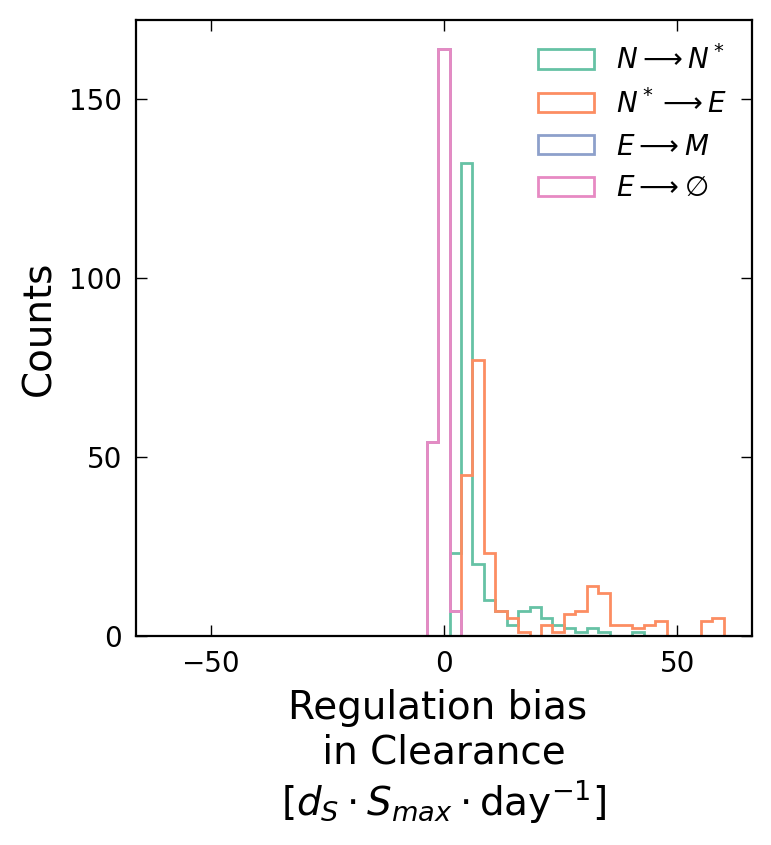

In [29]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(modules):
    data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data.I_0 <= I_min)]['intercept_'+r].values
    axs.hist(data, bins = np.linspace(-15*L0_max, 15*L0_max, 50), histtype = 'step', label = module_labels[i], color = cmap_colors[i], stacked = True);

axs.legend(fontsize = 10, ncol = 1)

axs.set_xlabel("Regulation bias \n in "+perf_labels[perf_choice], fontsize = 14)
axs.set_ylabel("Counts", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

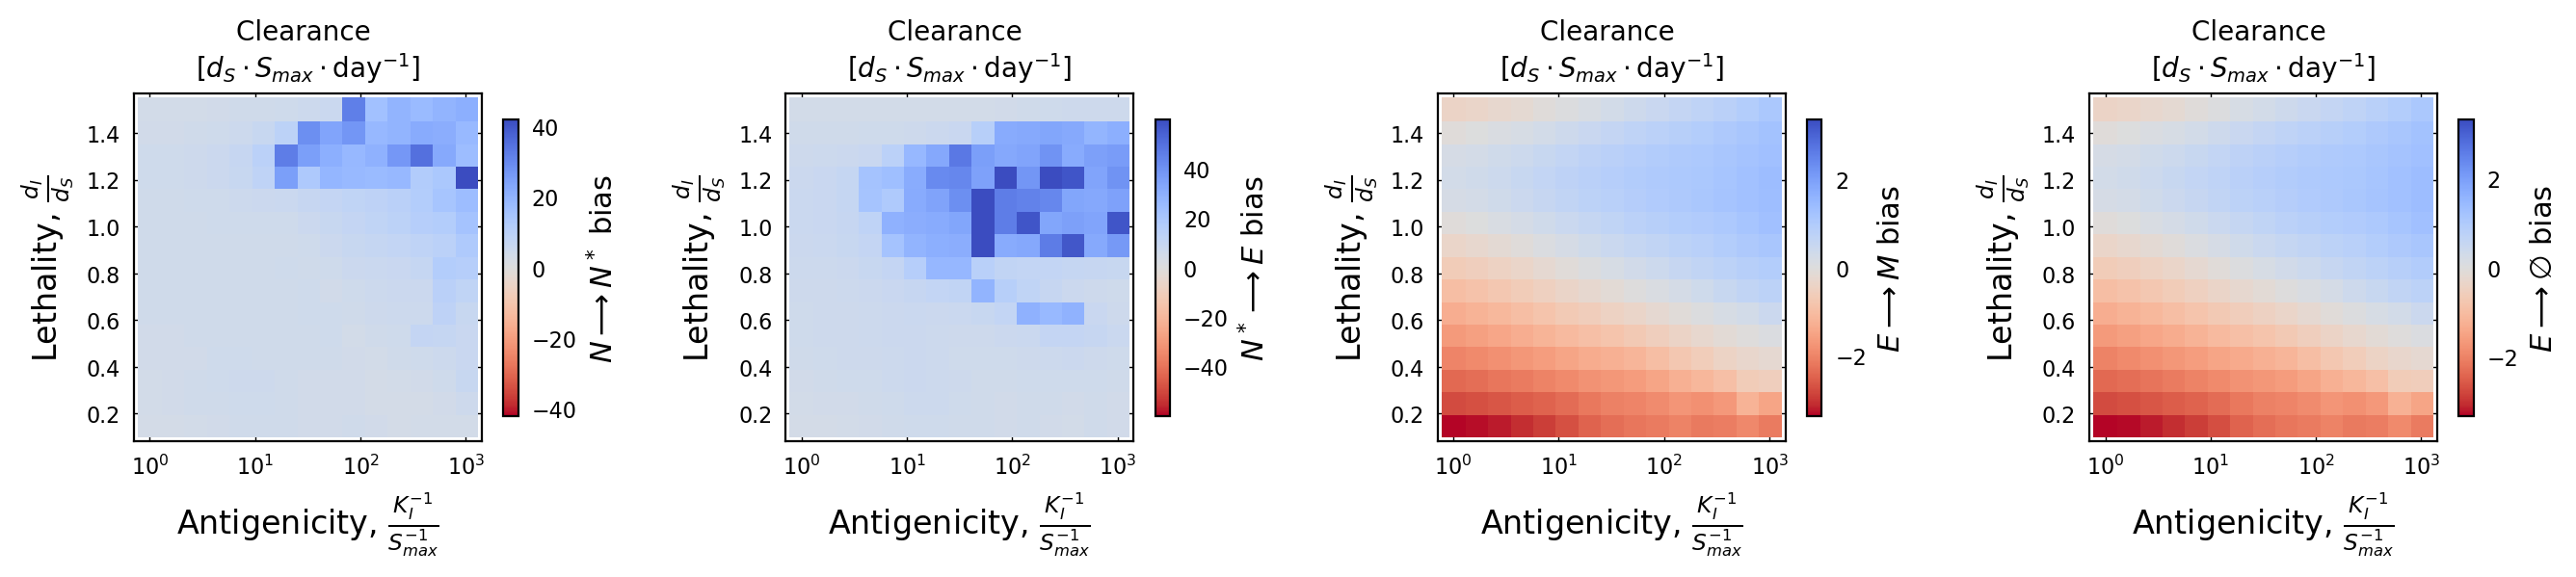

In [30]:
# Visualize optimal regulation
plots = [vir_vars[1], vir_vars[0]]
size = 1250/np.sqrt(len(infection_scenarios))

data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data.I_0 <= I_min)]

fig_c, axs = plt.subplots(1, len(modules), 
                          figsize=(len(modules)**2, 2*len(modules)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, r in enumerate(modules):
    z_varname = 'intercept_'+r
    z_label = module_labels[i]+" bias"
    z = data[z_varname]
    range = np.amax(np.abs(z))
    
    im = axs[i].scatter(S_0/data[x_varname] if x_varname == 'K_I' else data[x_varname],
                                 1/data[y_varname] if y_varname == 'K_I' else data[y_varname],
                      marker ='s', s = size, c = z, cmap='coolwarm_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize(vmin = -range, vmax = range))

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)
    axs[i].set_title(perf_labels[perf_choice], fontsize = 10.0)

    cb = fig_c.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.25, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig_c.subplots_adjust(wspace=.5, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

# plt.savefig('_figs/'+comment+'-optimal-reg-average_prot_tox_hmap'+'.png', dpi=150, bbox_inches="tight")

These intercept values are important because they tell you what the value of the observable would be if we ran our processes, without regulation, at half their maximal characteristic rates. A positive value means that the half-max rate leads to above-median performance/cost. It would be useful to convert these to rates.

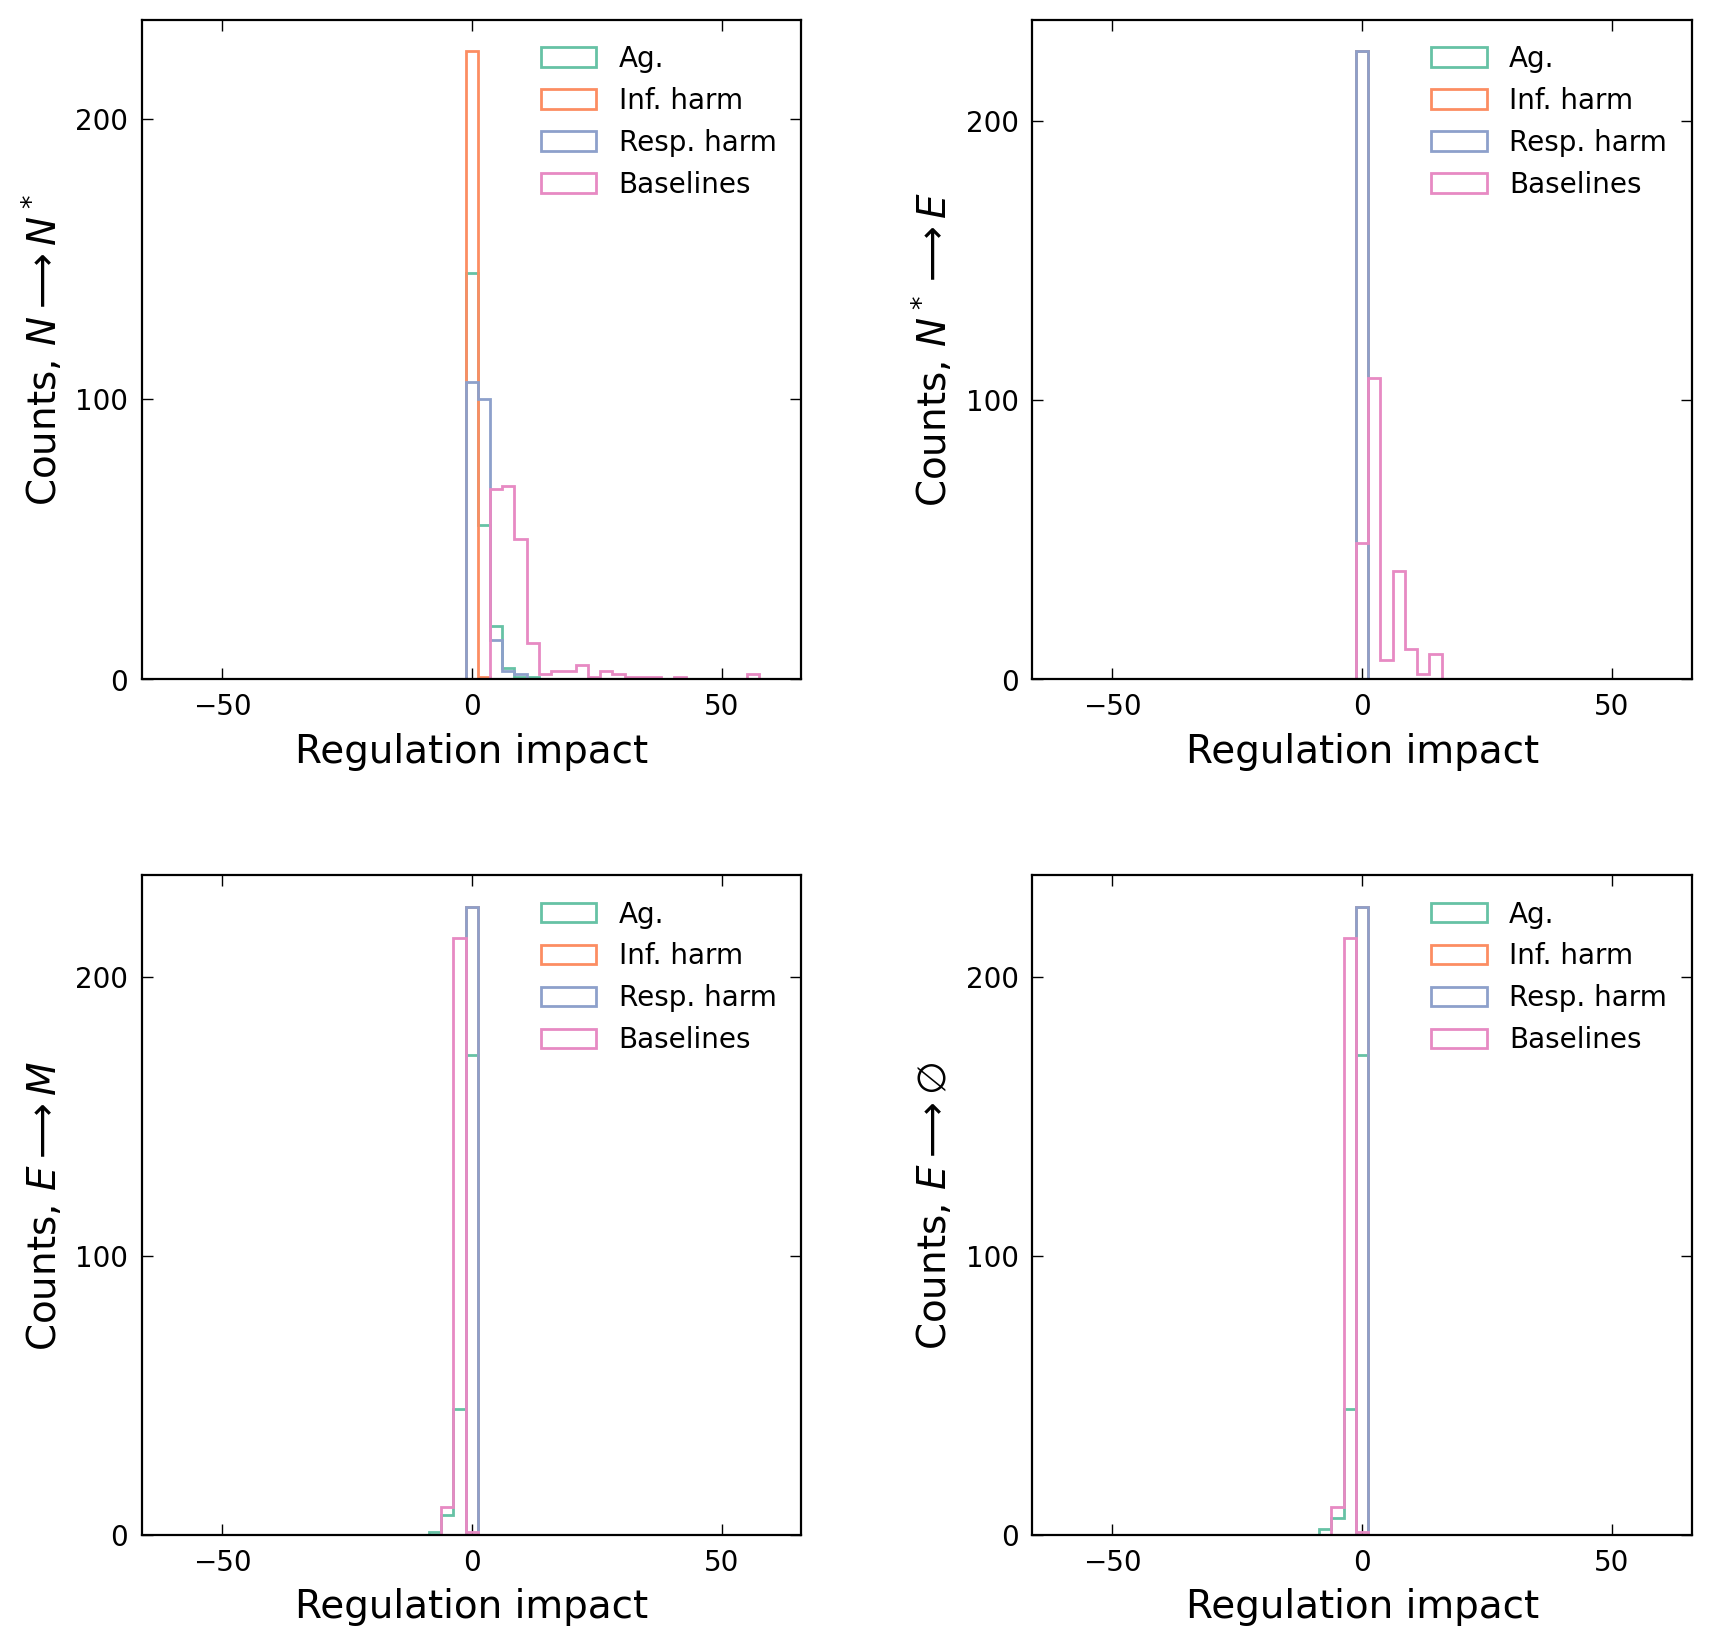

In [31]:
fig, axs = plt.subplots(2,2, figsize=(10,10), sharex=False, sharey=False)

for i, r in enumerate(reg):
    data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data.I_0 <= I_min)][r].values
    module = i // num_modules
    cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
    
    x, y = module // 2, module % 2
    axs[x,y].hist(data, bins = np.linspace(-15*L0_max, 15*L0_max, 50), histtype = 'step', label = signal_classes[i % num_modules], color = cmap_colors[i % num_modules], stacked = True);

    if (i % num_modules) == num_modules -1:
        axs[x,y].legend(fontsize = 10, ncol = 1)
    
        axs[x,y].set_xlabel("Regulation impact", fontsize = 14)
        axs[x,y].set_ylabel("Counts, "+module_labels[i // num_modules], fontsize = 14)
        axs[x,y].set_box_aspect(1)
        axs[x,y].minorticks_off()
        axs[x,y].locator_params(axis='y', nbins=4)
        axs[x,y].locator_params(axis='x', nbins=4)

fig.subplots_adjust(wspace=.35, hspace=.25)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

In [19]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)*(impact_data.b_I == 0.0)])

,y_max,y_min,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_myc_I,sigma_psi_myc_HI,sigma_psi_myc_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_Edie_I,sigma_psi_Edie_HI,sigma_psi_Edie_HE,sigma_L0_Edie,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_I,b_I,K_H,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,max_scaled_min_pS,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm


In [20]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)*(impact_data.b_I == b_C)])

,y_max,y_min,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_myc_I,sigma_psi_myc_HI,sigma_psi_myc_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_Edie_I,sigma_psi_Edie_HI,sigma_psi_Edie_HE,sigma_L0_Edie,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_I,b_I,K_H,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,max_scaled_min_pS,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
1352,5.308892,5.783744e-34,60.000000,15.479315,11.748807,31.852277,2.074571,0.489892,0.030768,1.110229,-1.221551,-0.284510,-0.915323,-1.093349,-1.219100,-0.282768,-0.913903,-1.092026,5.001772,3.419766,-2.314383,-2.316134,0.011273,0.000563,2.170072,0.569291,0.423116,1.147588,0.011897,0.006280,0.005834,0.005375,0.005468,0.002953,0.004478,0.004220,0.005455,0.002946,0.004469,0.004212,0.188120,0.018304,0.006966,0.006956,0.01,100000.0,0.1,100000.0,10.0,10000000.0,500000.0,0.213321,5.301304,0.0,0.000005,2.0,0.280632,0.758826,0.912341,2.821645,3.456836,1.188038,2.384108,-10.445414
1358,5.621265,3.635934e-40,60.000000,15.195733,18.007662,35.576827,1.624000,0.388530,0.063728,0.941191,-1.595442,-0.372968,-0.729095,-1.144271,-1.596063,-0.373274,-0.728190,-1.144589,4.530464,4.114907,-0.755551,-0.755641,0.009798,0.001249,2.032598,0.513431,0.604689,1.209129,0.015558,0.007543,0.006723,0.009156,0.008004,0.004216,0.005072,0.005060,0.008007,0.004217,0.005070,0.005061,0.148095,0.036958,0.005078,0.005078,0.01,100000.0,0.1,100000.0,100.0,10000000.0,500000.0,0.514164,5.607300,0.0,0.000068,2.0,0.589612,1.396487,0.920812,2.821645,3.456836,1.188038,3.309497,-10.445414
1364,5.683275,2.593670e-39,60.000000,14.952568,21.039428,38.195831,1.048218,0.261401,0.091696,0.710707,-1.847609,-0.440749,-0.793870,-1.306788,-1.848801,-0.441616,-0.794424,-1.307401,3.460762,4.140333,-0.026341,-0.025681,0.009800,0.001783,1.279540,0.323159,0.446469,0.813015,0.012561,0.008060,0.007581,0.011132,0.012430,0.005675,0.007011,0.008206,0.012442,0.005680,0.007017,0.008214,0.065219,0.047947,0.005899,0.005901,0.01,100000.0,0.1,100000.0,1000.0,10000000.0,500000.0,0.704498,5.700616,0.0,0.000699,2.0,0.815083,1.734112,0.927271,2.821645,3.456836,1.188038,3.621445,-10.445414
1370,5.341688,3.085661e-03,4.901598,4.294591,2.885634,8.132277,0.559151,0.495690,0.033504,1.207115,-0.462858,-0.455780,-1.107620,-1.326511,-0.461181,-0.462844,-1.112919,-1.331137,3.480989,3.837842,-2.607169,-2.613236,0.006651,0.000444,0.047147,0.040971,0.028247,0.076842,0.004166,0.004065,0.003634,0.004229,0.002520,0.002508,0.003988,0.004103,0.002524,0.002527,0.004010,0.004125,0.032268,0.014738,0.007010,0.007057,0.01,1000000.0,0.1,100000.0,10.0,10000000.0,500000.0,0.242455,5.333451,0.0,0.000011,2.0,0.222245,0.823701,0.824012,2.821645,1.404047,1.188038,2.422991,24.253500
1376,5.657109,4.554817e-39,5.660752,4.833067,4.532713,10.175401,0.428319,0.383928,0.050398,1.039720,-0.660350,-0.630145,-0.709167,-1.418529,-0.658016,-0.628565,-0.708259,-1.416933,3.492627,4.609597,-0.656653,-0.656533,0.006966,0.001050,0.070636,0.058327,0.056206,0.124329,0.005710,0.005585,0.005000,0.009319,0.004123,0.004046,0.004252,0.005688,0.004113,0.004038,0.004246,0.005676,0.041014,0.037506,0.003999,0.003997,0.01,1000000.0,0.1,100000.0,100.0,10000000.0,500000.0,0.590006,5.642168,0.0,0.000121,2.0,0.498994,1.494086,0.828515,2.821645,1.404047,1.188038,3.399072,24.253500
1382,5.752972,1.529898e-36,17.384277,17.376911,21.772797,42.352389,0.253827,0.224981,0.035148,0.771201,-0.879873,-0.833880,-0.946598,-1.870105,-0.881675,-0.834911,-0.946688,-1.870370,5.783990,4.553373,0.243650,0.244461,0.006947,0.001490,14.400239,14.400238,14.425472,32.417683,0.007618,0.007572,0.007341,0.016545,0.007289,0.007042,0.007662,0.012450,0.007299,0.00